In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, Ridge, Lasso

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score




In [3]:
df = pd.read_csv("WineQT.csv")

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [4]:
X = df.drop(columns=["quality", "Id"])
y = df["quality"]

print("Input shape:", X.shape)
print("Target shape:", y.shape)

Input shape: (1143, 11)
Target shape: (1143,)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [6]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [7]:
linear = LinearRegression()

linear.fit(X_train, y_train)
linear_pred = linear.predict(X_test)

In [8]:
ridge = Ridge(alpha=1.0)

ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)

In [9]:
lasso = Lasso(alpha=0.01)

lasso.fit(X_train, y_train)
lasso_pred = lasso.predict(X_test)

In [10]:
def evaluate(name, y_test, prediction):

    mae = mean_absolute_error(y_test, prediction)
    mse = mean_squared_error(y_test, prediction)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, prediction)

    return [name, mae, mse, rmse, r2]


results = []

results.append(
    evaluate("Linear Regression", y_test, linear_pred)
)

results.append(
    evaluate("Ridge", y_test, ridge_pred)
)

results.append(
    evaluate("Lasso", y_test, lasso_pred)
)


results_df = pd.DataFrame(
    results,
    columns=["Model", "MAE", "MSE", "RMSE", "R2"]
)

results_df

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,0.477340,0.380032,0.616468,0.317069
1,Ridge,0.477311,0.379881,0.616345,0.317341
2,Lasso,0.474115,0.369904,0.608197,0.335271


In [11]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Linear": linear.coef_,
    "Ridge": ridge.coef_,
    "Lasso": lasso.coef_
})

coefficients

,Feature,Linear,Ridge,Lasso
0,fixed acidity,0.087048,0.086838,0.022495
1,volatile acidity,-0.239122,-0.238646,-0.223573
2,citric acid,-0.066082,-0.065283,-0.013223
3,residual sugar,0.005379,0.005442,-0.000000
4,chlorides,-0.085649,-0.085712,-0.081140
5,free sulfur dioxide,0.019244,0.019222,0.000000
6,total sulfur dioxide,-0.072857,-0.072929,-0.060472
7,density,-0.058650,-0.058945,-0.017111
8,pH,-0.038087,-0.037865,-0.035157
9,sulphates,0.161578,0.161463,0.141083


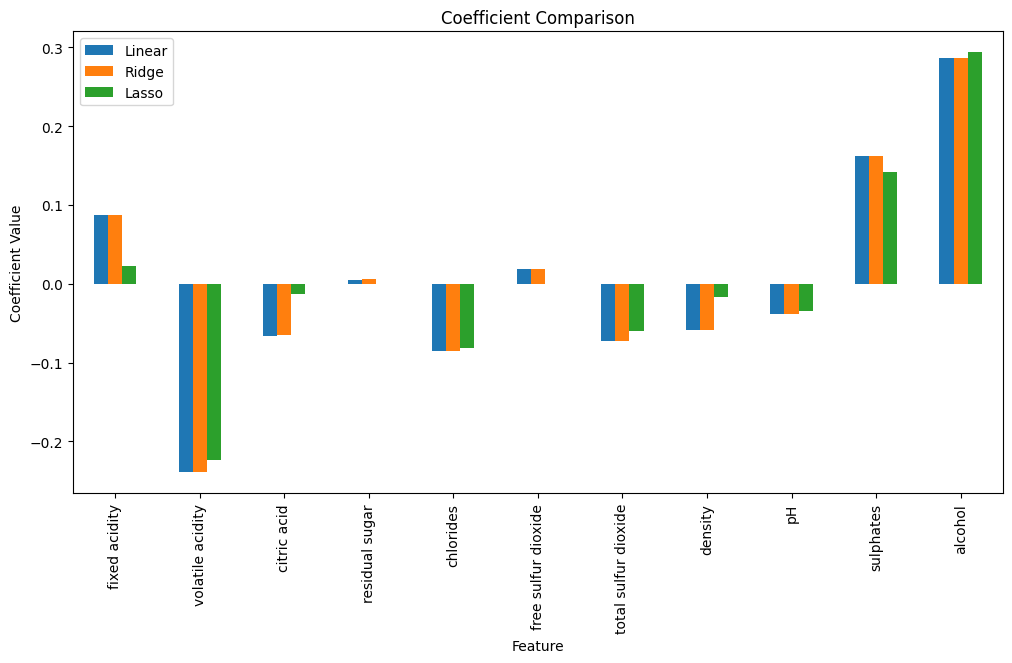

In [12]:
coefficients.set_index("Feature").plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Coefficient Comparison")
plt.ylabel("Coefficient Value")
plt.show()

# CONCLUSION

# Linear Regression gives a baseline model without regularization.

# Ridge slightly reduces the size of coefficients and helps control
# overfitting.

# Lasso reduces some coefficients to zero, which also performs
# feature selection.

# In this dataset, Lasso performs the best because it has the
# lowest MAE, MSE and RMSE and the highest R² score.

# Therefore, Lasso generalizes slightly better than Linear
# Regression and Ridge on the test data.